# Skeptical Agent: Inference Demo

This notebook demonstrates the **Skeptical Agent** interactive segmentation framework.
It will automatically download the necessary weights and sample data, then run inference using simulated user interactions (Points and Bounding Boxes).

**Note:** If running on Google Colab, ensure you are using a GPU runtime (**Runtime > Change runtime type > T4 GPU**) for faster processing.

In [2]:
# Install dependencies
!pip install nninteractive gdown SimpleITK matplotlib scipy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.5/178.5 kB 2.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.9/212.9 kB 11.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 8.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 

In [1]:
import os
import torch
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
import gdown
from scipy.ndimage import distance_transform_edt
from nnInteractive.inference.inference_session import nnInteractiveInferenceSession

nnUNet_raw is not defined and nnU-Net can only be used on data for which preprocessed files are already present on your system. nnU-Net cannot be used for experiment planning and preprocessing like this. If this is not intended, please read documentation/setting_up_paths.md for information on how to set this up properly.
nnUNet_preprocessed is not defined and nnU-Net can not be used for preprocessing or training. If this is not intended, please read documentation/setting_up_paths.md for information on how to set this up.
nnUNet_results is not defined and nnU-Net cannot be used for training or inference. If this is not intended behavior, please read documentation/setting_up_paths.md for information on how to set this up.


In [3]:
# --- Configuration ---
MODEL_FOLDER_URL = "https://drive.google.com/drive/folders/1qsqcGZWG4NcvL7lHRy6WffK8yx27Svec?usp=drive_link"
DATA_FOLDER_URL = "https://drive.google.com/drive/folders/18G4nRcDhmjYpHyJsSAlBF4kAhYGn1-W1?usp=drive_link"

MODEL_DIR = "SkepticalNet_v1.0"
DATA_DIR = "brats_sample"

def download_data():
    if not os.path.exists(MODEL_DIR):
        print(f"Downloading Model to {MODEL_DIR}...")
        gdown.download_folder(url=MODEL_FOLDER_URL, output=MODEL_DIR, quiet=False)

    if not os.path.exists(DATA_DIR):
        print(f"Downloading Data to {DATA_DIR}...")
        gdown.download_folder(url=DATA_FOLDER_URL, output=DATA_DIR, quiet=False)

download_data()

Retrieving folder contents


Retrieving folder 19CrwWt9-X6vDmknKghQg5xYtjlfLlvRE fold_0
Processing file 1LWuc0kc4miCw8ZI9Wc-x7a34edm4qa0l checkpoint_final.pth
Processing file 1RHQMJsn3kUP-TgGTcbs0INrMhKPoTrat dataset.json
Processing file 1yBwVs2SpMuekmTY5NdBLl8UAgsqMyvMd inference_session_class.json
Processing file 1b-uAZa6PVmmKuyL7jtPpzavtnjpdQrP8 plans.json


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1LWuc0kc4miCw8ZI9Wc-x7a34edm4qa0l
From (redirected): https://drive.google.com/uc?id=1LWuc0kc4miCw8ZI9Wc-x7a34edm4qa0l&confirm=t&uuid=52dbe3c8-c9e1-47ec-aada-38f504652acc
To: /content/SkepticalNet_v1.0/fold_0/checkpoint_final.pth
100%|██████████| 410M/410M [00:05<00:00, 80.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1RHQMJsn3kUP-TgGTcbs0INrMhKPoTrat
To: /content/SkepticalNet_v1.0/dataset.json
100%|██████████| 283/283 [00:00<00:00, 967kB/s]
Downloading...
From: https://drive.google.com/uc?id=1yBwVs2SpMuekmTY5NdBLl8UAgsqMyvMd
To: /content/SkepticalNet_v1.0/inference_session_class.json
100%|██████████| 121/121 [00:00<00:00, 444kB/s]
Downloading...
From: https://drive.google.com/uc?id=1b-uAZa6PVmmKuyL7jtPpzavtnjpdQrP8
To: /content/SkepticalNet_v1.0/plans.json
100%|██████████| 6.29k/6.29k [00:00<00:00, 16.4MB/s]

Processing file 1lTTHYyzhZO0FwvkZfoGTla57VHPFUXZz BraTS-GLI-00000-000-seg.nii.gz
Processing file 1GkyYE1wUUlZY8kO0hPNMldiasSU3V7zz BraTS-GLI-00000-000-t1c.nii.gz
Processing file 10TJe_poU20tiXcE_C-pk9_9X29vyGGsB BraTS-GLI-00000-000-t1n.nii.gz
Processing file 1rWAxwNxL8LbBYy4Au5wXWRVns4vhomiS BraTS-GLI-00000-000-t2f.nii.gz
Processing file 1bj8q5EFRbDLl2Q2E8czXVJlqRohNbW_s BraTS-GLI-00000-000-t2w.nii.gz


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1lTTHYyzhZO0FwvkZfoGTla57VHPFUXZz
To: /content/brats_sample/BraTS-GLI-00000-000-seg.nii.gz
100%|██████████| 49.9k/49.9k [00:00<00:00, 58.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1GkyYE1wUUlZY8kO0hPNMldiasSU3V7zz
To: /content/brats_sample/BraTS-GLI-00000-000-t1c.nii.gz
100%|██████████| 2.64M/2.64M [00:00<00:00, 19.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=10TJe_poU20tiXcE_C-pk9_9X29vyGGsB
To: /content/brats_sample/BraTS-GLI-00000-000-t1n.nii.gz
100%|██████████| 2.33M/2.33M [00:00<00:00, 18.7MB/s]
Downloading...
From: https://drive.google.com/uc?id=1rWAxwNxL8LbBYy4Au5wXWRVns4vhomiS
To: /content/brats_sample/BraTS-GLI-00000-000-t2f.nii.gz
100%|██████████| 2.53M/2.53M [00:00<00:00, 19.3MB/s]
Downloading...
From: https://drive.google.com/uc?id=1bj8q5EFRbDLl2Q2E8czXVJlqRohNbW_s
To: /content/brats_sample

In [3]:
# --- Helper Functions ---

def calculate_DT_probabilities(mask: np.ndarray, alpha: float = 8.0):
    """Calculates sampling probabilities based on distance transform."""
    distance_map = distance_transform_edt(mask)
    if np.max(distance_map) > 0:
        distance_map = distance_map / np.max(distance_map)
    distance_map = distance_map ** alpha
    total_sum = np.sum(distance_map)
    return distance_map / (total_sum if total_sum > 0 else 1)

def sample_from_array(arr: np.ndarray):
    """Samples an N-D index from a weight array using weighted random sampling."""
    arr = np.asarray(arr)
    if arr.size == 0 or np.sum(arr) == 0:
        return tuple(np.array(arr.shape) // 2)
    flat_arr = arr.flatten()
    probabilities = flat_arr / flat_arr.sum()
    sampled_idx = np.random.choice(flat_arr.size, p=probabilities)
    return np.unravel_index(sampled_idx, arr.shape)

def plot_result(image_np: np.ndarray, gt_mask_np: np.ndarray, pred_mask_np: np.ndarray, title: str):
    """Plots the segmentation result inline."""
    foreground_counts = np.sum(gt_mask_np, axis=(1, 2))
    slice_index = np.argmax(foreground_counts) if np.max(foreground_counts) > 0 else image_np.shape[0] // 2

    image_slice = image_np[slice_index]
    gt_mask_slice = gt_mask_np[slice_index]
    pred_mask_slice = pred_mask_np[slice_index]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(image_slice, cmap='gray')
    axes[0].set_title('Original MR Image')
    axes[0].axis('off')

    axes[1].imshow(image_slice, cmap='gray')
    axes[1].imshow(np.where(gt_mask_slice > 0, 1, 0), alpha=0.5, cmap='Reds')
    axes[1].set_title('Ground Truth (Red)')
    axes[1].axis('off')

    axes[2].imshow(image_slice, cmap='gray')
    axes[2].imshow(np.where(pred_mask_slice > 0, 1, 0), alpha=0.5, cmap='Blues')
    axes[2].set_title('Prediction (Blue)')
    axes[2].axis('off')

    plt.suptitle(f"{title} (Slice {slice_index})")
    plt.tight_layout()
    plt.show()

In [4]:
# --- Initialize Model ---
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

session = nnInteractiveInferenceSession(
    device=torch.device(device),
    use_torch_compile=False,
    verbose=False,
    torch_n_threads=os.cpu_count(),
    do_autozoom=True,
    use_pinned_memory=(device != "cpu"),
)

print("Loading model weights...")
session.initialize_from_trained_model_folder(MODEL_DIR)
print("Model loaded!")

Using device: cpu
Loading model weights...
Model loaded!


In [5]:
# --- Load & Preprocess Images ---
img_paths = [
    os.path.join(DATA_DIR, "BraTS-GLI-00000-000-t1n.nii.gz"),
    os.path.join(DATA_DIR, "BraTS-GLI-00000-000-t1c.nii.gz"),
    os.path.join(DATA_DIR, "BraTS-GLI-00000-000-t2w.nii.gz"),
    os.path.join(DATA_DIR, "BraTS-GLI-00000-000-t2f.nii.gz"),
]

images = [sitk.ReadImage(im_p) for im_p in img_paths]
image_arrays = [sitk.GetArrayFromImage(img).astype(np.float32) for img in images]
input_image = np.stack(image_arrays, axis=0) # Shape [4, D, H, W]

session.set_image(input_image)

# Setup Target Buffer
target_tensor = torch.zeros(input_image.shape[1:], dtype=torch.uint8)
session.set_target_buffer(target_tensor)

# Load GT for simulation
label = sitk.ReadImage(os.path.join(DATA_DIR, "BraTS-GLI-00000-000-seg.nii.gz"))
label_tensor = torch.from_numpy(sitk.GetArrayFromImage(label).astype(np.uint8))
print("Images and Ground Truth loaded.")

Images and Ground Truth loaded.


## Experiment 1: Necrosis (Point Interaction)
We simulate 3 positive clicks in the Necrotic core (Label 1).

Simulating 3 positive clicks...
Added new point interaction: center 1, scale [[62, 48, 88]]
Took 30.44 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 30.448s
Added new point interaction: center 1, scale [[59, 30, 74]]
Took 29.69 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 29.696s
Added new point interaction: center 1, scale [[69, 39, 83]]
Took 30.058 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 30.067s
Final Dice (Necrosis): 0.9162


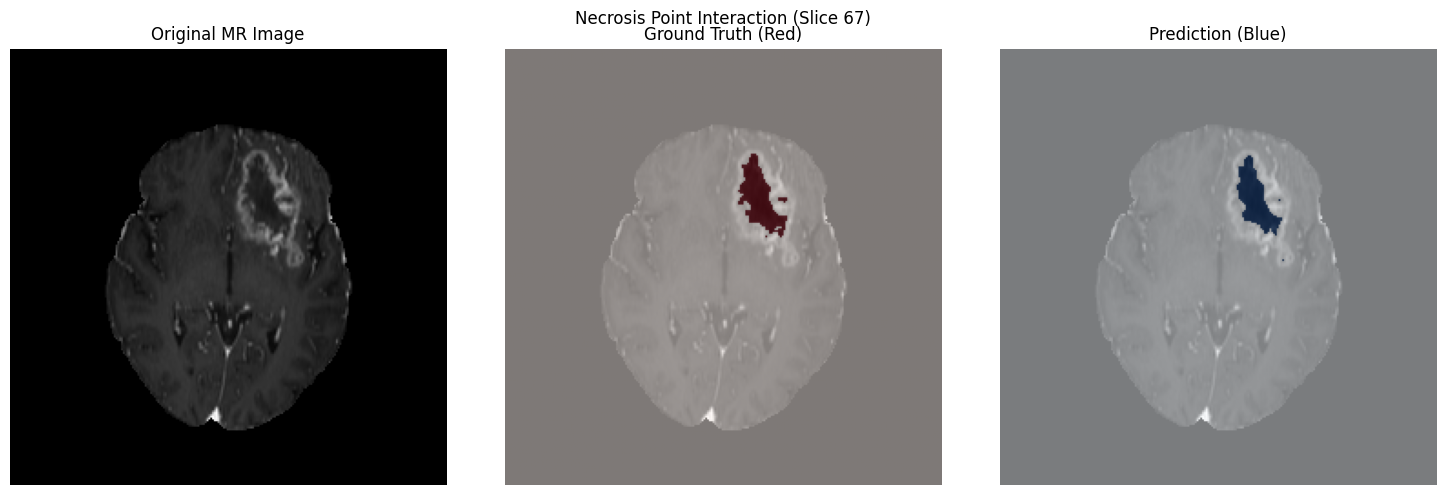

In [14]:
session.reset_interactions() # Clear previous interactions and target buffer

gt_ncr = (label_tensor == 1)
results = session.target_buffer.clone()

print("Simulating 3 positive clicks...")
for k in range(3):
    current_error = (gt_ncr * (1 - results)).numpy()
    if np.sum(current_error) == 0: break

    dt = calculate_DT_probabilities(current_error, alpha=8.0)
    fg_point = sample_from_array(dt)
    session.add_point_interaction(fg_point, include_interaction=True)
    results = session.target_buffer.clone()

dice_ncr = (2 * (results * gt_ncr).sum()) / (results.sum() + gt_ncr.sum())
print(f"Final Dice (Necrosis): {dice_ncr:.4f}")

%matplotlib inline
plot_result(input_image[1], gt_ncr.numpy(), results.numpy(), "Necrosis Point Interaction")

## Experiment 2: Edema (Point Interaction)
We simulate 3 positive clicks in the Edema region (Label 2).

Simulating 3 positive clicks...
Added new point interaction: center 1, scale [[71, 9, 82]]
Took 30.545 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 30.551s
Added new point interaction: center 1, scale [[79, 24, 86]]
Took 29.661 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 29.667s
Added new point interaction: center 1, scale [[72, 25, 73]]
Took 30.731 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 30.737s
Final Dice (Edema): 0.5780


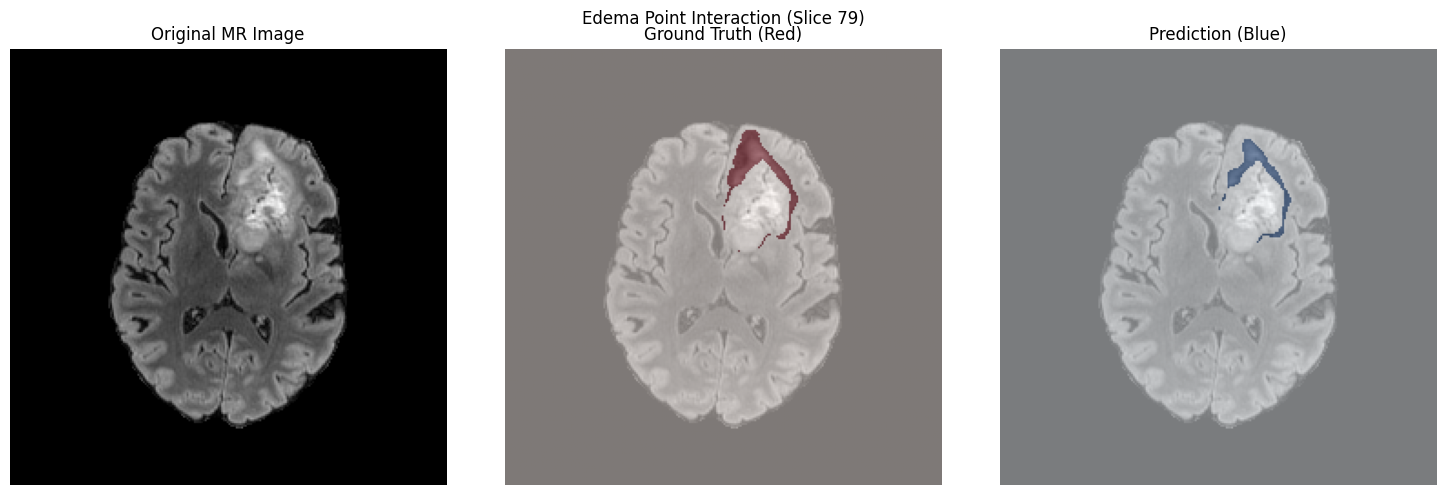

In [20]:
session.reset_interactions() # Clear previous interactions and target buffer

gt_ed = (label_tensor == 2)
results = session.target_buffer.clone()

print("Simulating 3 positive clicks...")
for k in range(3):
    current_error = (gt_ed * (1 - results)).numpy()
    if np.sum(current_error) == 0: break

    dt = calculate_DT_probabilities(current_error, alpha=8.0)
    fg_point = sample_from_array(dt)
    session.add_point_interaction(fg_point, include_interaction=True)
    results = session.target_buffer.clone()

dice_ed = (2 * (results * gt_ed).sum()) / (results.sum() + gt_ed.sum())
print(f"Final Dice (Edema): {dice_ed:.4f}")
plot_result(input_image[3], gt_ed.numpy(), results.numpy(), "Edema Point Interaction")

## Experiment 3: Whole Tumor (Bounding Box)
We simulate a single Bounding Box interaction covering the Whole Tumor (Labels > 0).

Added new bbox interaction: center 1, scale [[68, 42, 88]]
Took 29.881 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 29.887s
Final Dice (Whole Tumor): 0.9251


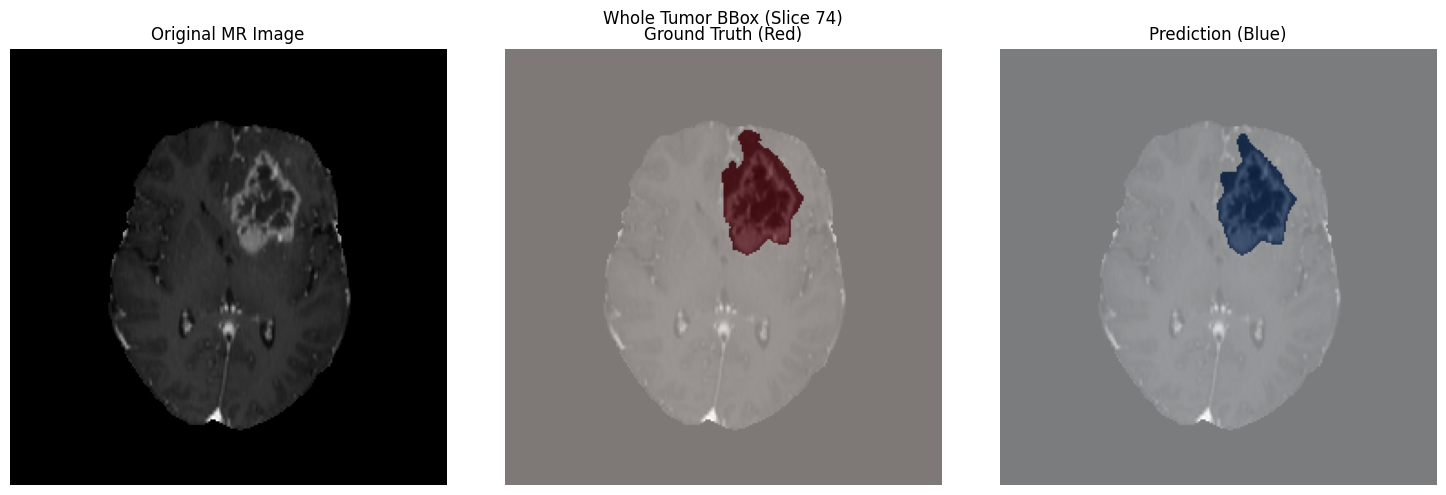

In [16]:
session.reset_interactions() # Clear previous interactions and target buffer

gt_wt = (label_tensor > 0)

# Calculate BBox from GT
foreground_indices = torch.nonzero(gt_wt)
if foreground_indices.numel() > 0:
    min_indices = tuple(torch.min(foreground_indices, dim=0).values.tolist())
    max_indices = tuple(torch.max(foreground_indices, dim=0).values.tolist())

    # Simulate user drawing box on the middle axial slice
    middle_z = (min_indices[0] + max_indices[0]) // 2

    bbox_coordinates = [
        [middle_z, middle_z + 1],          # Z range
        [min_indices[1], max_indices[1]],  # Y range
        [min_indices[2], max_indices[2]]   # X range
    ]

    session.add_bbox_interaction(bbox_coordinates, include_interaction=True)
    results = session.target_buffer.clone()

    dice_wt = (2 * (results * gt_wt).sum()) / (results.sum() + gt_wt.sum())
    print(f"Final Dice (Whole Tumor): {dice_wt:.4f}")
    plot_result(input_image[1], gt_wt.numpy(), results.numpy(), "Whole Tumor BBox")
else:
    print("No Whole Tumor found in GT.")

## Experiment 4: Invalid Point Interaction (Healthy Tissue)
We simulate 3 positive point interactions on healthy brain tissue to assess the suppression of invalid user prompts.

In [26]:
# Define healthy tissue
backgr = (label_tensor < 1).numpy()  # Non-lesion area
brain = input_image[1] > 0  # Brain area (including lesion)
h_t = np.logical_and(backgr, brain)  # Healthy brain tissue

print("Simulating 3 positive clicks on healthy brain tissue...")

# Calculate sampling probabilities
dt = calculate_DT_probabilities(h_t, alpha=8.0)

for k in range(3):
    session.reset_interactions() # Clear previous interactions

    bg_point = sample_from_array(dt)
    session.add_point_interaction(bg_point, include_interaction=True)
    results = session.target_buffer.clone()

    if results.sum() > 1:
        print(f" --Point interaction {k+1}: Failed! Network hallucinated {results.sum()} voxels.\n")
    else:
        print(f" --Point interaction {k+1}: Success! Interaction successfully suppressed.\n")

Simulating 3 positive clicks on healthy brain tissue...
Added new point interaction: center 1, scale [[76, 112, 63]]
Took 32.378 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 32.385s
 --Point interaction 1: Success! Interaction successfully suppressed.

Added new point interaction: center 1, scale [[91, 112, 79]]
Took 33.514 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 33.52s
 --Point interaction 2: Success! Interaction successfully suppressed.

Added new point interaction: center 1, scale [[75, 113, 43]]
Took 32.326 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 32.332s
 --Point interaction 3: Success! Interaction successfully suppressed.



## Experiment 4: Invalid Bounding Box Interaction (Healthy Tissue)
We simulate a positive bounding box interaction on healthy brain tissue to assess the suppression of invalid user prompts.

In [22]:
session.reset_interactions() # Clear previous interactions and target buffer

bg_point = sample_from_array(dt)
bbox_rad = 8
z_max, y_max, x_max = h_t.shape

# Clamped coordinates for an Axial Bounding Box centered around bg_point
bbox_coordinates = [
    [bg_point[0], min(bg_point[0] + 1, z_max)],                             # Z range (1 slice thick)
    [max(0, bg_point[1] - bbox_rad), min(bg_point[1] + bbox_rad, y_max)],   # Y range
    [max(0, bg_point[2] - bbox_rad), min(bg_point[2] + bbox_rad, x_max)]    # X range
]

session.add_bbox_interaction(bbox_coordinates, include_interaction=True)
results = session.target_buffer.clone()

if results.sum() > 1:
    print(f" --BBox: Failed! Network hallucinated {results.sum()} voxels.\n")
else:
    print(" --BBox: Success! Interaction successfully suppressed.\n")

Added new bbox interaction: center 1, scale [[100, 102, 48]]
Took 37.834 s for initial prediction at zoom out factor 1
No zoom out necessary
No refinement necessary
Done. Total time 37.843s
 --BBox: Success! Interaction successfully suppressed.

